In [1]:
import numpy as np
import pandas as pd
import swc.aeon.io as io
import swc.aeon.io.reader as reader
from swc.aeon.schema.streams import Device
from swc.aeon.schema import core as stream
from swc.aeon.io.reader import Csv
import swc.aeon.io.video as video
import os
from dotmap import DotMap
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice
import cv2

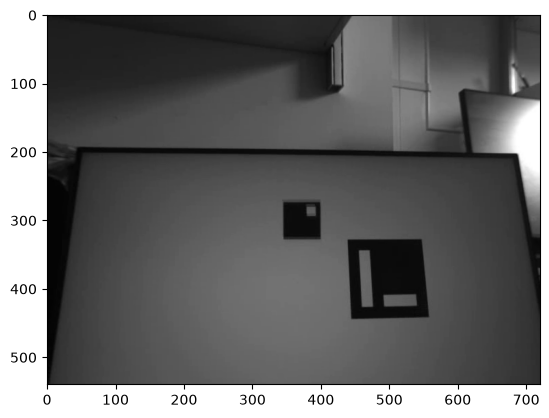

In [308]:
## Extracting camera frames
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T09-28-00/"

def get_camera_data(root: str, name: str):
    path = os.path.join(root, f"{name}/{name}.csv")
    data = pd.read_csv(path, header=0, names=["time"])
    data["_frame"] = data.index
    data["_path"] = os.path.splitext(path)[0] + ".avi"
    data.set_index("time", inplace=True)

    return data

def get_index_at_time(camera_data: pd.DataFrame, time: float):
    slice = camera_data.loc[camera_data.index <= time]
    return slice.iloc[[-1]]["_frame"].values[0]

def get_frame_at_index(camera_data: pd.DataFrame, index: int):
    return next(islice(camera_data, index, index+1))

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

# frame = get_frame_at_index(subject_frames, get_index_at_time(subject_camera, 1361.066912))
# frame = get_frame_at_index(subject_frames, get_index_at_time(subject_camera, 1370.4801600000001))

frame = get_frame_at_index(subject_frames, 651)

plt.figure()
plt.imshow(frame)

[(array([[342, 266],
       [342, 318],
       [394, 318],
       [394, 266]], dtype=int32), (368, 292)), (array([[491, 221],
       [495, 336],
       [609, 334],
       [599, 221]], dtype=int32), (548, 278))]


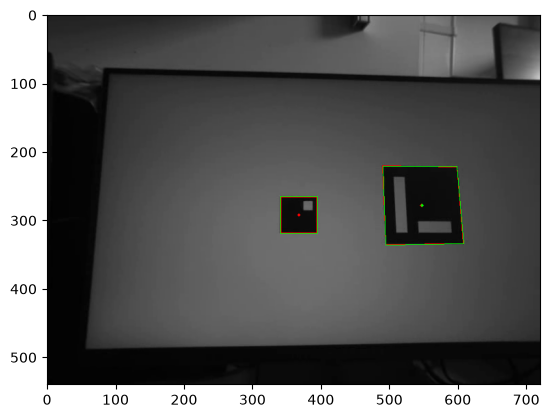

In [311]:
def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs(np.dot(d1, d2) / np.sqrt(np.dot(d1, d1)*np.dot(d2, d2)))

## Landmark detection
def detect_landmarks(frame, blur: int, thresh1: int, thresh2: int):
    blurred = cv2.GaussianBlur(frame, (blur, blur), 0)
    edges = cv2.Canny(blurred, thresh1, thresh2)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    squares = []
    for cnt in contours:
        cnt_len = cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, 0.02 * cnt_len, True)
        if len(cnt) == 4 and cv2.contourArea(cnt) > 2000 and cv2.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos(cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4]) for i in range(4)])
            if max_cos < 0.3:
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                squares.append((cnt, (cx, cy)))

    return squares

squares = detect_landmarks(frame, 1, 200, 100)
print(squares)
track_contour = squares[0] if cv2.contourArea(squares[0][0]) > cv2.contourArea(squares[1][0]) else squares[1]
aruco_contour = squares[1] if cv2.contourArea(squares[0][0]) > cv2.contourArea(squares[1][0]) else squares[0]

contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
contours = cv2.circle(contours, track_contour[1], 2, (0, 255, 0), -1)
contours = cv2.circle(contours, aruco_contour[1], 2, (255, 0, 0), -1)
plt.figure()
plt.imshow(contours)

      frame_index  detected_squares  track_centroid_x  track_centroid_y  \
0             0.0               1.0               NaN               NaN   
1             1.0               1.0               NaN               NaN   
2             2.0               1.0               NaN               NaN   
3             3.0               1.0               NaN               NaN   
4             4.0               2.0             367.0             294.0   
...           ...               ...               ...               ...   
2164       2164.0               2.0             368.0             290.0   
2165       2165.0               2.0             368.0             291.0   
2166       2166.0               2.0             368.0             291.0   
2167       2167.0               2.0             368.0             292.0   
2168       2168.0               2.0             368.0             292.0   

      track_area  aruco_centroid_x  aruco_centroid_y  aruco_area  
0            NaN               N

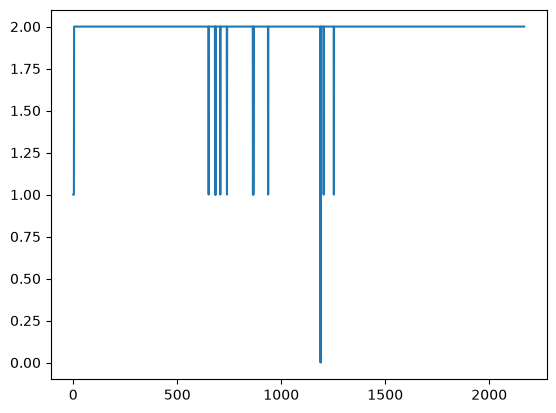

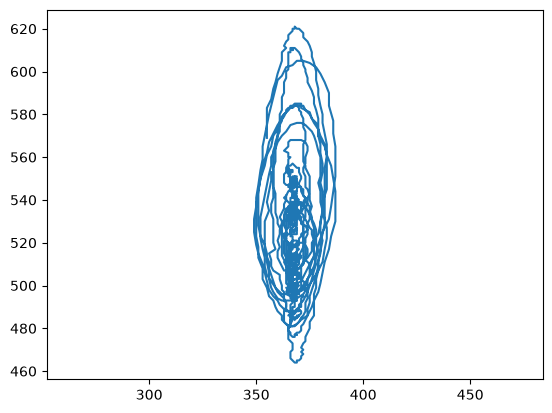

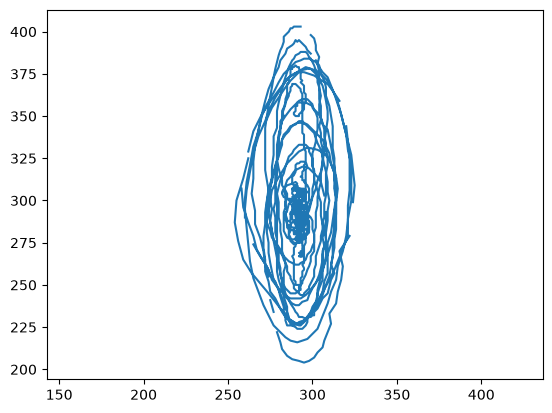

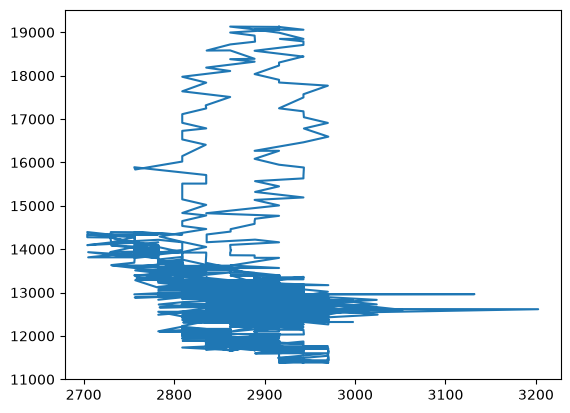

In [331]:
## Video run
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T09-28-00/"

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

vid_path = os.path.join(base_dir, "AnnotatedResult.mp4")
result = pd.DataFrame(columns=["frame_index", "detected_squares", "track_centroid_x", "track_centroid_y", "track_area", "aruco_centroid_x", "aruco_centroid_y", "aruco_area"])

annotated_frames = []
n_squares = []
for f, frame in enumerate(subject_frames):
    detected_squares = 0
    blur = -1
    while detected_squares < 2:
        blur += 2
        squares = detect_landmarks(frame, blur, 200, 100)
        detected_squares = len(squares)
        if blur > 40:
            squares = detect_landmarks(frame, 1, 200, 100)
            break

    n_squares.append(len(squares))
    track_centroid = (np.nan, np.nan)
    aruco_centroid = (np.nan, np.nan)
    track_area = np.nan
    aruco_area = np.nan
    if (len(squares) == 2):
        track_contour = squares[0] if (squares[0][1][0] < squares[1][1][0]) else squares[1]
        aruco_contour = squares[1] if (squares[0][1][0] < squares[1][1][0]) else squares[0]

        track_centroid = track_contour[1]
        aruco_centroid = aruco_contour[1]
        track_area = cv2.contourArea(track_contour[0])
        aruco_area = cv2.contourArea(aruco_contour[0])
        contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
        contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
        contours = cv2.circle(contours, track_centroid, 2, (0, 255, 0), -1)
        contours = cv2.circle(contours, aruco_centroid, 2, (255, 0, 0), -1)
    else:
        contours = frame

    annotated_frames.append(contours)
    result.loc[f] = [f, len(squares), track_centroid[0], track_centroid[1], track_area, aruco_centroid[0], aruco_centroid[1], aruco_area]

video.export(annotated_frames, vid_path, 60)

print(result)
plt.figure()
plt.plot(n_squares)

plt.figure()
plt.plot(result["track_centroid_x"], result["aruco_centroid_x"])
plt.axis('equal')

plt.figure()
plt.plot(result["track_centroid_y"], result["aruco_centroid_y"])
plt.axis('equal')

plt.figure()
plt.plot(result["track_area"], result["aruco_area"])